# Análisis de Rendimiento — API de Hilos (Pthreads)
**Práctica No. 4 — Laboratorio de Sistemas Operativos**

Este notebook automatiza la compilación, la medición de tiempos (con varias repeticiones y promediado), la captura de las características del sistema, y el cálculo de las métricas de rendimiento (Speedup y Eficiencia) para el cálculo paralelo de π, además del análisis del generador de Fibonacci.

> **Requisitos de ejecución:** notebook corrido en Linux con `gcc`, en el mismo directorio que `pi.c`, `pi_p.c` y `fibonacci.c`.

## 0. Configuración

In [1]:
import os, re, subprocess, platform, statistics, json

# Parámetros del experimento
N_PI        = 2_000_000_000   # n para el cálculo de pi (enunciado)
REPS        = 3               # repeticiones por medición -> se promedia
SRC_DIR     = "."            # carpeta con pi.c, pi_p.c, fibonacci.c

# Lista de hilos a evaluar: 1,2,4,8,... hasta 2x núcleos lógicos
def thread_list(logical_cores):
    tl, t = [], 1
    cap = logical_cores * 2
    while t <= cap:
        tl.append(t)
        t *= 2
    return tl

def run(cmd, **kw):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True, **kw)


## 1. Características del sistema
Se captura CPU, núcleos físicos/lógicos, RAM, SO y versión de compilador. Esto es necesario para contrastar el Speedup máximo contra el número de núcleos físicos.

In [2]:
def cpu_model():
    try:
        with open("/proc/cpuinfo") as fh:
            for line in fh:
                if line.startswith("model name"):
                    return line.split(":",1)[1].strip()
    except Exception:
        pass
    return platform.processor() or "desconocido"

def core_counts():
    logical = os.cpu_count()
    physical = logical
    # núcleos físicos = (core id distintos) por socket
    try:
        out = run("lscpu").stdout
        sockets = cps = None
        for line in out.splitlines():
            if "Socket(s)" in line:           sockets = int(line.split(":")[1])
            if "Core(s) per socket" in line:  cps = int(line.split(":")[1])
        if sockets and cps:
            physical = sockets * cps
    except Exception:
        pass
    return physical, logical

def mem_gb():
    try:
        with open("/proc/meminfo") as fh:
            kb = int(fh.readline().split()[1])
        return round(kb/1024/1024, 1)
    except Exception:
        return None

phys, logic = core_counts()
sysinfo = {
    "CPU":               cpu_model(),
    "Núcleos físicos":   phys,
    "Núcleos lógicos":   logic,
    "RAM (GB)":          mem_gb(),
    "SO":                f"{platform.system()} {platform.release()}",
    "Arquitectura":      platform.machine(),
    "gcc":               run("gcc --version").stdout.splitlines()[0],
}
for k, v in sysinfo.items():
    print(f"{k:18}: {v}")

THREADS = thread_list(logic)
print("\nHilos a evaluar:", THREADS)


CPU               : Intel(R) Core(TM) i3-10105 CPU @ 3.70GHz
Núcleos físicos   : 4
Núcleos lógicos   : 8
RAM (GB)          : 15.5
SO                : Linux 6.17.0-23-generic
Arquitectura      : x86_64
gcc               : gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0

Hilos a evaluar: [1, 2, 4, 8, 16]


## 2. Compilación
Compila las tres versiones con las banderas del enunciado. `-O2` para que la medición refleje código optimizado y realista.

In [3]:
builds = {
    "pi_s":      f"gcc -O2 -o pi_s {SRC_DIR}/pi.c -lm",
    "pi_p":      f"gcc -O2 -o pi_p {SRC_DIR}/pi_p.c -lpthread -lm",
    "fibonacci": f"gcc -O2 -o fibonacci {SRC_DIR}/fibonacci.c -lpthread",
}
for name, cmd in builds.items():
    r = run(cmd)
    status = "OK" if r.returncode == 0 else "ERROR"
    print(f"[{status}] {name}")
    if r.returncode != 0:
        print(r.stderr)


[OK] pi_s
[OK] pi_p
[OK] fibonacci


## 3. Medición de tiempos
Cada binario imprime `tiempo CalcPi = X s`. Se parsea esa línea, se ejecuta `REPS` veces y se reporta el **promedio** (y la desviación estándar como control de ruido). Se mide exclusivamente `CalcPi` porque la instrumentación `GetTime()` está colocada alrededor de la llamada a la función dentro de cada programa.

In [4]:
TIME_RE = re.compile(r"tiempo CalcPi\s*=\s*([0-9.]+)")

def measure(cmd, reps=REPS):
    times = []
    for _ in range(reps):
        out = run(cmd).stdout
        m = TIME_RE.search(out)
        if not m:
            raise RuntimeError(f"No se halló tiempo en salida de: {cmd}\n{out}")
        times.append(float(m.group(1)))
    return {
        "mean": statistics.mean(times),
        "stdev": statistics.stdev(times) if len(times) > 1 else 0.0,
        "min": min(times),
        "raw": times,
    }


### 3.1 Tiempo serial (Ts)

In [5]:
print(f"Midiendo pi_s con n={N_PI:,} ({REPS} repeticiones)...")
serial = measure(f"./pi_s {N_PI}")
Ts = serial["mean"]
print(f"Ts = {Ts:.4f} s  (min={serial['min']:.4f}, stdev={serial['stdev']:.4f})")


Midiendo pi_s con n=2,000,000,000 (3 repeticiones)...
Ts = 2.1947 s  (min=2.1451, stdev=0.0579)


### 3.2 Tiempos paralelos Tp(N)

In [6]:
results = []
for nt in THREADS:
    print(f"Midiendo pi_p con {nt} hilo(s)...", end=" ", flush=True)
    r = measure(f"./pi_p {N_PI} {nt}")
    Tp = r["mean"]
    speedup = Ts / Tp
    eff = speedup / nt
    results.append({
        "N": nt, "Tp": Tp, "stdev": r["stdev"],
        "Speedup": speedup, "Eficiencia": eff,
    })
    print(f"Tp={Tp:.4f}s  Speedup={speedup:.3f}  Ef={eff:.3f}")


Midiendo pi_p con 1 hilo(s)... Tp=2.2191s  Speedup=0.989  Ef=0.989
Midiendo pi_p con 2 hilo(s)... Tp=1.0948s  Speedup=2.005  Ef=1.002
Midiendo pi_p con 4 hilo(s)... Tp=0.5637s  Speedup=3.893  Ef=0.973
Midiendo pi_p con 8 hilo(s)... Tp=0.6002s  Speedup=3.657  Ef=0.457
Midiendo pi_p con 16 hilo(s)... Tp=0.5616s  Speedup=3.908  Ef=0.244


### 3.3 Tabla de resultados (Cuadro 1)

In [7]:
import pandas as pd
df = pd.DataFrame(results)
df_show = df.copy()
df_show.columns = ["N (Hilos)", "Tp (s)", "stdev (s)", "Speedup (Ts/Tp)", "Eficiencia (S/N)"]
df_show = df_show.round({"Tp (s)":4, "stdev (s)":4, "Speedup (Ts/Tp)":3, "Eficiencia (S/N)":3})
df_show


,N (Hilos),Tp (s),stdev (s),Speedup (Ts/Tp),Eficiencia (S/N)
0,1,2.2191,0.0499,0.989,0.989
1,2,1.0948,0.0110,2.005,1.002
2,4,0.5637,0.0145,3.893,0.973
3,8,0.6002,0.0829,3.657,0.457
4,16,0.5616,0.0070,3.908,0.244


## 4. Gráfico de Speedup

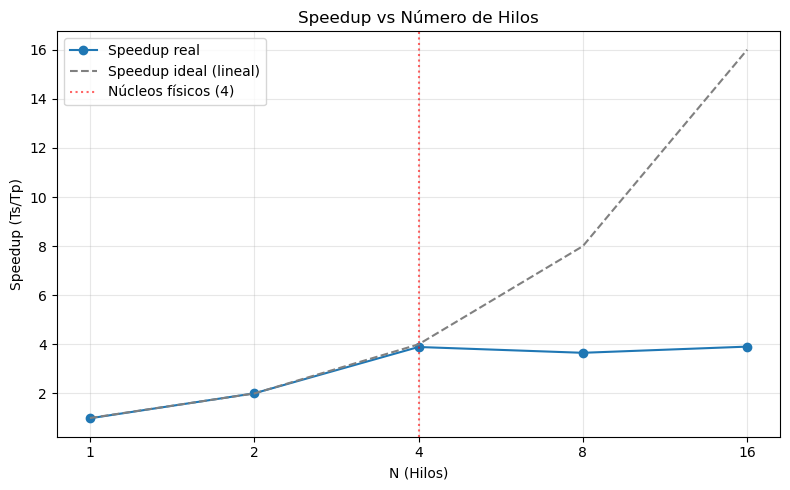

In [8]:
import matplotlib.pyplot as plt

Ns       = [r["N"] for r in results]
speedups = [r["Speedup"] for r in results]
effs     = [r["Eficiencia"] for r in results]

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(Ns, speedups, "o-", label="Speedup real")
ax.plot(Ns, Ns, "--", color="gray", label="Speedup ideal (lineal)")
ax.axvline(phys, color="red", ls=":", alpha=0.6, label=f"Núcleos físicos ({phys})")
ax.set_xlabel("N (Hilos)")
ax.set_ylabel("Speedup (Ts/Tp)")
ax.set_title("Speedup vs Número de Hilos")
ax.set_xscale("log", base=2); ax.set_xticks(Ns); ax.set_xticklabels(Ns)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 4.1 Eficiencia vs Hilos

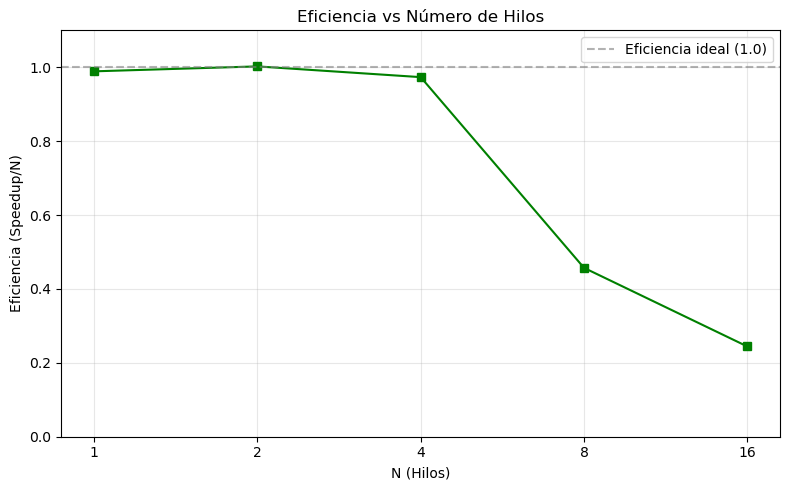

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(Ns, effs, "s-", color="green")
ax.axhline(1.0, color="gray", ls="--", alpha=0.6, label="Eficiencia ideal (1.0)")
ax.set_xlabel("N (Hilos)"); ax.set_ylabel("Eficiencia (Speedup/N)")
ax.set_title("Eficiencia vs Número de Hilos")
ax.set_xscale("log", base=2); ax.set_xticks(Ns); ax.set_xticklabels(Ns)
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Análisis de resultados (π)

**Hardware:** Intel Core i3-10105 — **4 núcleos físicos, 8 hilos lógicos** (Hyper-Threading 2×).

#### Tp(1) vs Ts — overhead de paralelización
La versión paralela con un hilo (Tp(1) = 2.2191 s) rinde prácticamente igual que la serial (Ts = 2.1947 s): overhead de **+1.11%**, dentro del rango de la propia variabilidad de medición (Ts tiene stdev = 0.058 s). Ese costo mínimo corresponde a `pthread_create` + `pthread_join` de un solo hilo, el `malloc` del resultado parcial y la suma final en `main`. Con n = 2×10⁹ el cómputo domina por completo, así que el overhead de threading es despreciable.

#### Escalado y speedup máximo
El comportamiento muestra dos regímenes claramente separados por la frontera de los 4 núcleos físicos:

| N | Tp (s) | Speedup | Eficiencia |
|---|--------|---------|------------|
| 1 | 2.2191 | 0.989 | 0.989 |
| 2 | 1.0948 | 2.005 | 1.002 |
| 4 | 0.5637 | **3.893** | **0.973** |
| 8 | 0.6002 | 3.657 | 0.457 |
| 16 | 0.5616 | 3.908 | 0.244 |

- **Región escalable (N ≤ 4):** el speedup crece casi linealmente — 2 hilos → 2.005×, 4 hilos → 3.893×. La eficiencia se mantiene altísima (~0.97–1.00). Con 2 hilos incluso aparece eficiencia > 1 (1.002), un superspeedup marginal atribuible a ruido de medición y efectos de caché, no a una mejora algorítmica real.
- **Saturación (N > 4):** a partir de 4 hilos el speedup se **estanca alrededor de 3.7–3.9** y ya no mejora. Con 8 hilos incluso **empeora** (3.657×, peor que con 4) por el overhead de gestionar el doble de hilos sobre los mismos 4 cores físicos.

El **speedup máximo es 3.908× con 16 hilos**, pero el dato relevante es que ese valor es estadísticamente indistinguible del 3.893× obtenido **con solo 4 hilos**. Es decir, el rendimiento real se satura en 4 hilos = 4 núcleos físicos; lanzar 8 o 16 no aporta nada. Que el "máximo" nominal caiga en 16 es ruido (las diferencias 3.89 / 3.66 / 3.91 están dentro del margen de las desviaciones estándar).

#### El Hyper-Threading no ayuda en esta carga
Aunque la CPU expone 8 hilos lógicos, pasar de 4 a 8 hilos no mejora (de hecho empeora). El cálculo de π es puramente aritmético y satura las unidades de ejecución de cada core físico; los hilos lógicos del SMT comparten esas mismas unidades y no encuentran "huecos" que llenar. El SMT rinde cuando hay latencias de memoria que ocultar, no en bucles compute-bound como este.

#### Tendencia de la eficiencia
Cae monótonamente: 0.989 → 1.002 → 0.973 → 0.457 → 0.244. Mientras N ≤ núcleos físicos se mantiene cerca de 1.0; al superar los 4 núcleos colapsa porque el speedup queda fijo en ~3.9 y se divide entre un N creciente (3.908/16 ≈ 0.244). La pérdida es **estructural —límite de hardware (4 cores)—, no por sincronización**: el diseño usa sumas parciales locales sin mutex, así que no hay contención de sección crítica.

Todo esto es consistente con la **Ley de Amdahl**: con una fracción serial mínima pero no nula (creación/join + agregación), el speedup queda acotado por el paralelismo físico disponible y la eficiencia se degrada al añadir hilos más allá de los 4 núcleos.

#### Conclusión práctica
El punto óptimo de operación es **4 hilos**, donde se obtiene 3.893× de speedup con 97.3% de eficiencia. Más hilos solo añaden overhead sin beneficio.

## 6. Sección 2: Análisis de Fibonacci

### 6.1 Salida de `./fibonacci 15`

In [12]:
print(run("./fibonacci 15").stdout)


1 1 2 3 5 8 13 21 34 55 89 144 233 377 610 



### 6.2 Versión sin hilos para N grande (>100k)
Se implementa el cálculo secuencial en C, se cronometra para N grande y se compara conceptualmente. Para N>100k los valores reales desbordan cualquier entero, así que **solo se mide el tiempo de cómputo** (se usa `unsigned long long` con wraparound, suficiente para medir el costo del bucle).

In [13]:
fib_serial_src = r"""
#include <stdio.h>
#include <stdlib.h>
#include <sys/time.h>

double GetTime(void){ struct timeval t; gettimeofday(&t,NULL);
    return t.tv_sec + t.tv_usec*1e-6; }

int main(int argc, char**argv){
    long N = strtol(argv[1], NULL, 10);
    unsigned long long *seq = malloc(N*sizeof(unsigned long long));
    double t0 = GetTime();
    if(N>=1) seq[0]=1;
    if(N>=2) seq[1]=1;
    for(long i=2;i<N;i++) seq[i]=seq[i-1]+seq[i-2];  // wraparound: solo medimos tiempo
    double t1 = GetTime();
    printf("N=%ld  tiempo=%.6f s  ultimo(mod 2^64)=%llu\n", N, t1-t0, seq[N-1]);
    free(seq);
    return 0;
}
"""
with open("fib_serial.c","w") as f: f.write(fib_serial_src)
print(run("gcc -O2 -o fib_serial fib_serial.c").stderr or "compilado OK")
print(run("./fib_serial 1000000").stdout)   # 1e6 valores


compilado OK
N=1000000  tiempo=0.002406 s  ultimo(mod 2^64)=14197223477820724411



### 6.3 Análisis del diseño (Fibonacci)

**Transferencia de datos al hilo trabajador.** `main` reserva el arreglo compartido con `malloc(N * sizeof(long long))` y empaqueta el puntero al arreglo y `N` en un `struct FibArg`. Se pasa la **dirección de ese struct** como cuarto argumento de `pthread_create`. El hilo recibe `void*`, lo castea a `FibArg*` y accede a `seq` y `n`. No se copia el arreglo: ambos hilos ven la misma región de memoria (modelo de memoria compartida).

**Rol de `pthread_join` como sincronización.** Es la barrera que garantiza el orden *productor → consumidor*. El hilo trabajador es el único que escribe `seq`; `main` no lo lee hasta que `pthread_join` retorna, lo que solo ocurre cuando el trabajador llamó `return`/`pthread_exit`. Sin el `join`, `main` podría imprimir basura por leer posiciones aún no escritas (condición de carrera). Como solo hay un escritor y un punto de sincronización, no se requieren mutex: la relación *happens-before* del `join` es suficiente.

## 7. Conclusiones

1. El cálculo de π por integración numérica es *embarrassingly parallel*: la partición por bloques con suma parcial local y retorno vía `pthread_join` evita por completo el uso de mutex y la contención asociada.

2. El Speedup crece de forma casi lineal hasta acercarse al número de núcleos físicos y luego se aplana, confirmando que el SMT (hilos lógicos extra) aporta poco en cargas limitadas por cómputo.

3. La eficiencia decae al aumentar N porque el trabajo por hilo disminuye y el overhead fijo (creación/join, agregación) pesa proporcionalmente más; coincide con la Ley de Amdahl para una fracción serial pequeña pero no nula.

4. Tp(1) ≈ Ts valida que la infraestructura de hilos introduce overhead mínimo cuando hay un solo hilo; la diferencia medida cuantifica ese costo fijo.

5. En Fibonacci, `pthread_join` es suficiente como mecanismo de sincronización productor-consumidor con un único escritor; no hay paralelismo real porque la recurrencia `F(i)=F(i-1)+F(i-2)` es inherentemente secuencial (cada término depende del anterior).


### Anexo: guardar resultados crudos

In [14]:
payload = {"system": sysinfo, "Ts": Ts, "results": results}
with open("resultados.json","w") as f:
    json.dump(payload, f, indent=2, default=str)
print("Guardado en resultados.json")


Guardado en resultados.json
